# Word2Vec from Scratch: Context Becomes Geometry

## Goal

Train a compact skip-gram Word2Vec model with negative sampling, inspect learned
neighborhoods, and visualize how words used in similar contexts cluster together.

The original course prototype depended on a roughly 1.6 GB pretrained model.
This version implements the learning objective directly on a controlled synthetic
corpus, so every input and every learned relationship is inspectable.

## Setup

Install `requirements-course-demos.txt`. This notebook uses only PyTorch,
NumPy, pandas, scikit-learn, and Matplotlib. It makes no network requests and
writes no model artifact.

Because the corpus is deliberately small and synthetic, the result demonstrates
the mechanism—not the coverage or quality of a production embedding model.

In [1]:
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))

print(f"torch={torch.__version__}; device=cpu; seed={SEED}")

torch=2.14.0; device=cpu; seed=42


## Steps

### 1. Build a controlled corpus

Words inside each category appear in interchangeable sentence frames. Word2Vec
never sees the category names during training; those labels are used only afterward
to color the projection and evaluate nearest-neighbor structure.

In [2]:
groups = {
    "fruit": ["apple", "banana", "orange", "pear"],
    "animal": ["cat", "dog", "horse", "rabbit"],
    "vehicle": ["car", "truck", "bus", "train"],
}

contexts = {
    "fruit": [["fresh", "snack"], ["sweet", "food"], ["ripe", "market"], ["grows", "garden"]],
    "animal": [["friendly", "pet"], ["living", "creature"], ["needs", "care"], ["moves", "outside"]],
    "vehicle": [["carries", "people"], ["uses", "engine"], ["travels", "route"], ["moves", "fast"]],
}

rng = random.Random(SEED)
corpus = []
for _ in range(200):
    for group, words in groups.items():
        shuffled_words = words.copy()
        rng.shuffle(shuffled_words)
        for word in shuffled_words:
            for phrase in contexts[group]:
                corpus.append([word, *phrase])
                corpus.append([phrase[0], word, phrase[1]])
rng.shuffle(corpus)

token_counts = Counter(token for sentence in corpus for token in sentence)
vocabulary = sorted(token_counts)
token_to_id = {token: index for index, token in enumerate(vocabulary)}

print(f"sentences={len(corpus):,}; tokens={sum(token_counts.values()):,}; vocabulary={len(vocabulary)}")
print("example:", " ".join(corpus[0]))

sentences=19,200; tokens=57,600; vocabulary=35
example: truck moves fast


### 2. Convert each sentence into skip-gram pairs

A center word is trained to score its real neighboring words above randomly
sampled negative words. The embedding table learned for this proxy task becomes
the word-vector space.

In [3]:
window_size = 2
pairs = []
for sentence in corpus:
    token_ids = [token_to_id[token] for token in sentence]
    for center_position, center_id in enumerate(token_ids):
        left = max(0, center_position - window_size)
        right = min(len(token_ids), center_position + window_size + 1)
        for context_position in range(left, right):
            if context_position != center_position:
                pairs.append((center_id, token_ids[context_position]))

center_ids = torch.tensor([center for center, _ in pairs], dtype=torch.long)
context_ids = torch.tensor([context for _, context in pairs], dtype=torch.long)

negative_distribution = torch.tensor(
    [token_counts[token] ** 0.75 for token in vocabulary], dtype=torch.float32
)
negative_distribution /= negative_distribution.sum()

print(f"positive skip-gram pairs={len(pairs):,}")

positive skip-gram pairs=115,200


In [4]:
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocabulary_size, embedding_size):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocabulary_size, embedding_size)
        self.context_embeddings = nn.Embedding(vocabulary_size, embedding_size)
        nn.init.uniform_(self.center_embeddings.weight, -0.5 / embedding_size, 0.5 / embedding_size)
        nn.init.zeros_(self.context_embeddings.weight)

    def forward(self, centers, positive_contexts, negative_contexts):
        center_vectors = self.center_embeddings(centers)
        positive_scores = (center_vectors * self.context_embeddings(positive_contexts)).sum(dim=1)
        negative_vectors = self.context_embeddings(negative_contexts)
        negative_scores = torch.bmm(negative_vectors, center_vectors.unsqueeze(2)).squeeze(2)
        return -(F.logsigmoid(positive_scores) + F.logsigmoid(-negative_scores).sum(dim=1)).mean()


model = SkipGramNegativeSampling(len(vocabulary), embedding_size=24)
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
generator = torch.Generator().manual_seed(SEED)
loss_history = []

for epoch in range(25):
    permutation = torch.randperm(len(center_ids), generator=generator)
    epoch_loss = 0.0
    for start in range(0, len(permutation), 1024):
        batch_indices = permutation[start : start + 1024]
        negative_ids = torch.multinomial(
            negative_distribution,
            len(batch_indices) * 5,
            replacement=True,
            generator=generator,
        ).reshape(len(batch_indices), 5)

        loss = model(center_ids[batch_indices], context_ids[batch_indices], negative_ids)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_indices)

    loss_history.append(epoch_loss / len(permutation))

pd.DataFrame({"epoch": np.arange(1, 26), "negative_sampling_loss": loss_history}).tail()

,epoch,negative_sampling_loss
20,21,1.265842
21,22,1.276358
22,23,1.270397
23,24,1.267832
24,25,1.270080


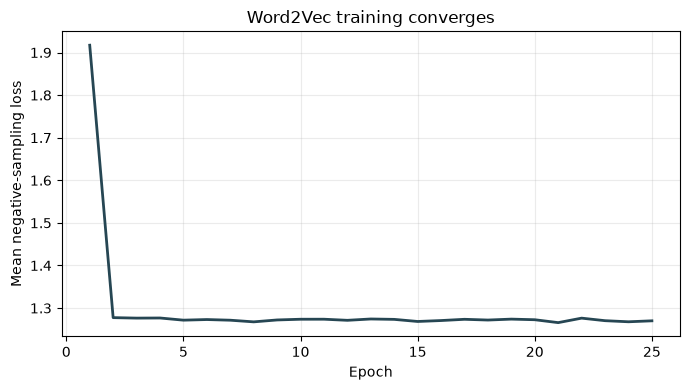

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(loss_history) + 1), loss_history, color="#264653", linewidth=2)
ax.set(xlabel="Epoch", ylabel="Mean negative-sampling loss", title="Word2Vec training converges")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3. Query learned neighborhoods

In [6]:
embedding_matrix = F.normalize(model.center_embeddings.weight.detach(), dim=1)


def most_similar(word, top_n=5):
    query_id = token_to_id[word]
    similarities = embedding_matrix @ embedding_matrix[query_id]
    similarities[query_id] = -1
    neighbor_ids = torch.topk(similarities, top_n).indices.tolist()
    return [(vocabulary[index], float(similarities[index])) for index in neighbor_ids]


neighbor_rows = []
for query in ["apple", "cat", "car"]:
    for rank, (neighbor, similarity) in enumerate(most_similar(query, 5), start=1):
        neighbor_rows.append(
            {"query": query, "rank": rank, "neighbor": neighbor, "cosine_similarity": similarity}
        )

pd.DataFrame(neighbor_rows).style.format({"cosine_similarity": "{:.3f}"})

,query,rank,neighbor,cosine_similarity
0,apple,1,orange,0.996
1,apple,2,banana,0.996
2,apple,3,pear,0.994
3,apple,4,ripe,0.446
4,apple,5,fresh,0.430
5,cat,1,dog,0.998
6,cat,2,rabbit,0.998
7,cat,3,horse,0.997
8,cat,4,fast,0.455
9,cat,5,needs,0.368


### 4. Project the learned vectors to two dimensions

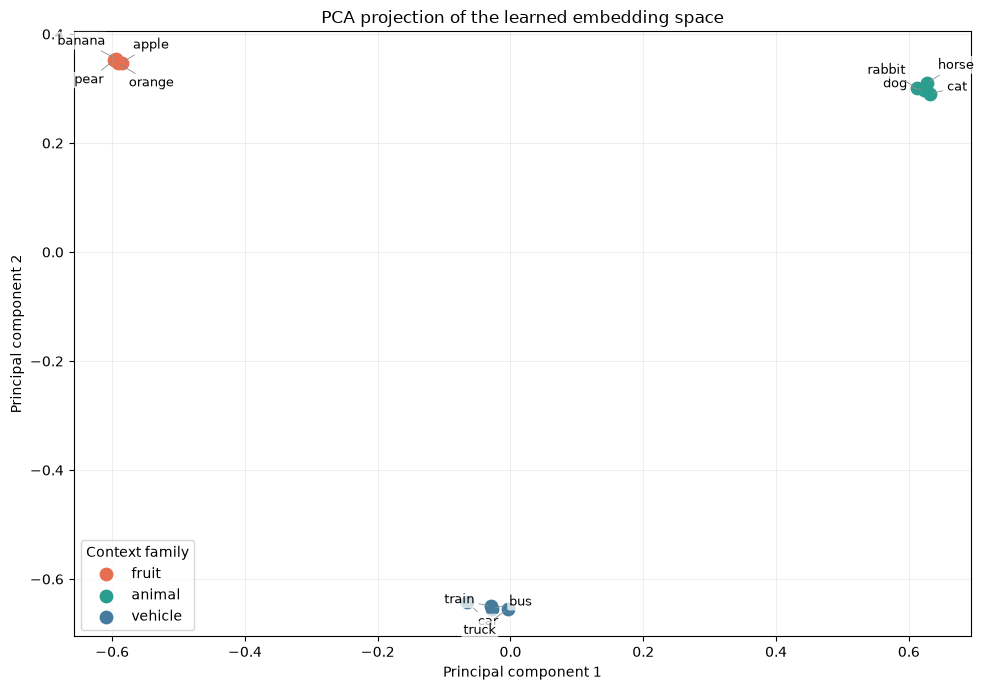

In [7]:
category_words = [word for words in groups.values() for word in words]
category_lookup = {word: group for group, words in groups.items() for word in words}
vectors = np.vstack([embedding_matrix[token_to_id[word]].numpy() for word in category_words])
coordinates = PCA(n_components=2).fit_transform(vectors)

palette = {"fruit": "#e76f51", "animal": "#2a9d8f", "vehicle": "#457b9d"}
fig, ax = plt.subplots(figsize=(10, 7))
for group in groups:
    mask = np.array([category_lookup[word] == group for word in category_words])
    ax.scatter(coordinates[mask, 0], coordinates[mask, 1], s=80, color=palette[group], label=group)
label_offsets = [(8, 8), (-8, 8), (8, -10), (-8, -10), (12, 0), (-12, 0)]
for index, (word, (x_coordinate, y_coordinate)) in enumerate(zip(category_words, coordinates)):
    offset_x, offset_y = label_offsets[index % len(label_offsets)]
    ax.annotate(
        word,
        (x_coordinate, y_coordinate),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        ha="left" if offset_x >= 0 else "right",
        va="bottom" if offset_y >= 0 else "top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        arrowprops={"arrowstyle": "-", "color": "0.55", "linewidth": 0.6},
    )
ax.set(title="PCA projection of the learned embedding space", xlabel="Principal component 1", ylabel="Principal component 2")
ax.legend(title="Context family")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Checks

In [8]:
candidate_ids = torch.tensor([token_to_id[word] for word in category_words])
correct_neighbors = 0
neighbor_total = 0

for word in category_words:
    similarities = embedding_matrix[candidate_ids] @ embedding_matrix[token_to_id[word]]
    self_position = category_words.index(word)
    similarities[self_position] = -1
    nearest_positions = torch.topk(similarities, 3).indices.tolist()
    nearest_words = [category_words[position] for position in nearest_positions]
    correct_neighbors += sum(category_lookup[neighbor] == category_lookup[word] for neighbor in nearest_words)
    neighbor_total += len(nearest_words)

category_precision = correct_neighbors / neighbor_total

assert np.isfinite(loss_history).all()
assert loss_history[-1] < loss_history[0]
assert embedding_matrix.shape == (len(vocabulary), 24)
assert torch.allclose(torch.linalg.vector_norm(embedding_matrix, dim=1), torch.ones(len(vocabulary)), atol=1e-5)
assert category_precision >= 0.90

print(f"Checks passed: loss fell {loss_history[0]:.3f} → {loss_history[-1]:.3f}; category-neighbor precision={category_precision:.1%}.")

Checks passed: loss fell 1.917 → 1.270; category-neighbor precision=100.0%.


## Next Steps

- Train on a large, documented natural-language corpus and evaluate on held-out similarity or analogy benchmarks.
- Compare skip-gram with CBOW, FastText, and contextual transformer embeddings.
- Audit nearest neighbors for stereotypes and other corpus-derived biases.
- Remember that PCA distorts the original 24-dimensional distances; it is a view, not the embedding itself.

Word2Vec learns distributional regularities: words become close because the
training data places them in similar contexts. The clean clusters here are a
property of the controlled corpus, not evidence that a small model understands
the real-world concepts.